In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plotsettings import *
import limpy.theory as lt

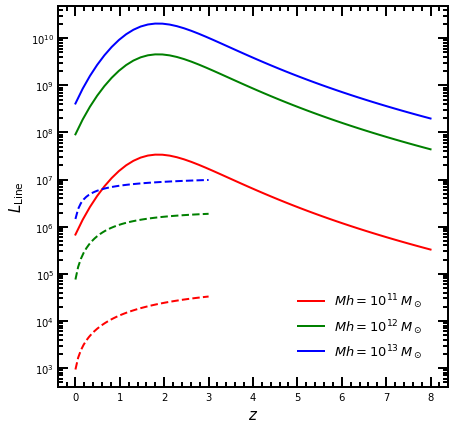

In [2]:
# Plot L_CII for different halo mass and redshift using LCII-Mhalo fitting formula
z=np.linspace(0, 8, num=50)
z_co=np.linspace(0, 3, num=50)

#for CII(J=1-0)
l_cii11=lt.mhalo_to_lline(10**11,z, line_name='CII')
l_cii12=lt.mhalo_to_lline(10**12,z, line_name='CII')
l_cii13=lt.mhalo_to_lline(10**13,z, line_name='CII')

#for CO(J=1-0)
l_co11=lt.mhalo_to_lline(10**11,z_co, line_name='CO10')
l_co12=lt.mhalo_to_lline(10**12,z_co, line_name='CO10')
l_co13=lt.mhalo_to_lline(10**13,z_co, line_name='CO10')


lw=2.0
plt.plot(z, l_cii11, lw=lw, color="r", label=r'$Mh=10^{11}\,M_\odot$')
plt.plot(z, l_cii12, lw=lw, color="g", label=r'$Mh=10^{12}\,M_\odot$')
plt.plot(z, l_cii13, lw=lw, color="b", label=r'$Mh=10^{13}\,M_\odot$')

plt.plot(z_co, l_co11, lw=lw, ls='--', color="r")
plt.plot(z_co, l_co12, lw=lw, ls='--',color="g")
plt.plot(z_co, l_co13, lw=lw, ls='--',color="b")

plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$L_{\rm Line}$')
plt.legend(loc=0, frameon=False)

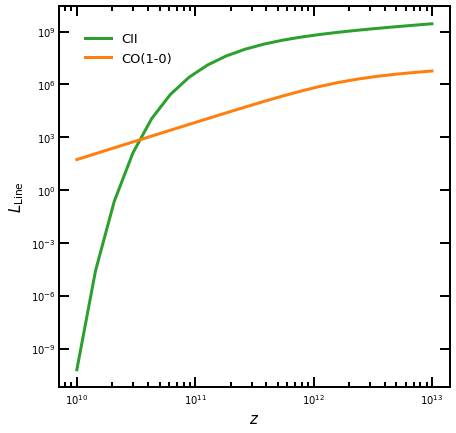

In [3]:
z=0.5
m=np.logspace(10,13,num=20)
l_ciim=lt.mhalo_to_lline(m,z, line_name='CII')
l_co10m=lt.mhalo_to_lline(m,z, line_name='CO10')

plt.plot(m,l_ciim,lw=3,color='C2', label='CII')
plt.plot(m,l_co10m,lw=3,color='C1', label='CO(1-0)')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$L_{\rm Line}$')
plt.legend(loc=0, frameon=False)

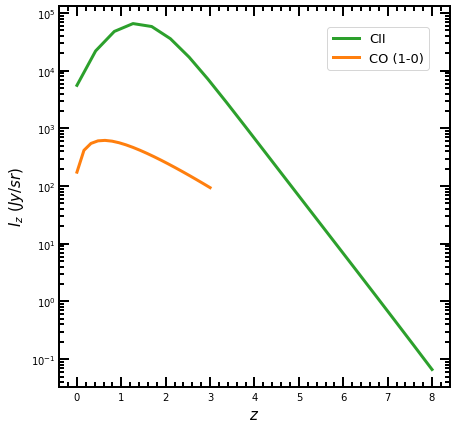

In [10]:
# Plot average intensity of CII and CO lines
z=np.linspace(0, 8, num=20)
z_co=np.linspace(0, 3, num=20)

nu_rest_CII=1900
nu_rest_CO10=115#Ghz

Icii=[lt.I_nu(zz,nu_rest_CII, line_name='CII') for zz in z]
ICO10=Iav=[lt.I_nu(z1,nu_rest_CO10, line_name='CO10') for z1 in z_co]
plt.plot(z, Icii, lw=3.0, color='C2',label="CII")
plt.plot(z_co, ICO10, lw=3.0, color='C1',label="CO (1-0)")

plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$I_z\,\,(Jy/sr)$')
plt.legend(loc=0)

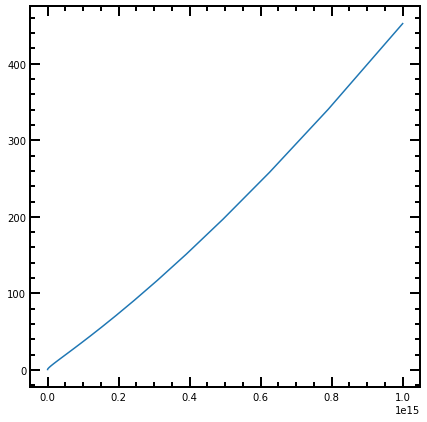

In [5]:
z=1.0
m=np.logspace(10,15)
b=lt.bias_dm(m,z)
plt.plot(m,b)


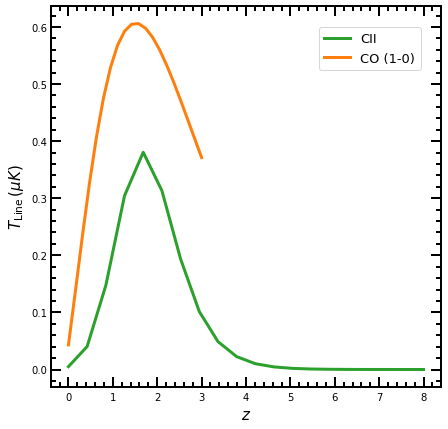

In [12]:
# Plot T_line for CII and CO lines
T_cii=[lt.T_line(zz,nu_rest_CII,line_name="CII",fduty=0.1)*1e6 for zz in z]
T_co10=[lt.T_line(zz,nu_rest_CO10,line_name="CO10",fduty=0.1)*1e6 for zz in z_co]

plt.plot(z, T_cii, lw=3.0, color='C2',label="CII")
plt.plot(z_co, T_co10, lw=3.0, color='C1',label="CO (1-0)")

#plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$T_{\rm Line}\,(\mu K)$')
plt.legend(loc=0)

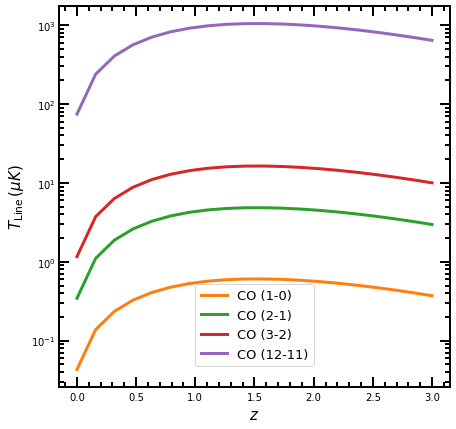

In [13]:
#CO lines
T_co10=[lt.T_line(zz,nu_rest_CO10,line_name="CO10",fduty=0.1)*1e6 for zz in z_co]
T_co21=[lt.T_line(zz,nu_rest_CO10,line_name="CO21",fduty=0.1)*1e6 for zz in z_co]
T_co32=[lt.T_line(zz,nu_rest_CO10,line_name="CO32",fduty=0.1)*1e6 for zz in z_co]
T_co1211=[lt.T_line(zz,nu_rest_CO10,line_name="CO1211",fduty=0.1)*1e6 for zz in z_co]


plt.plot(z_co, T_co10, lw=3.0, color='C1',label="CO (1-0)")
plt.plot(z_co, T_co21, lw=3.0, color='C2',label="CO (2-1)")
plt.plot(z_co, T_co32, lw=3.0, color='C3',label="CO (3-2)")
plt.plot(z_co, T_co1211, lw=3.0, color='C4',label="CO (12-11)")

#plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$T_{\rm Line}\,(\mu K)$')
plt.legend(loc=0)
plt.yscale("log")

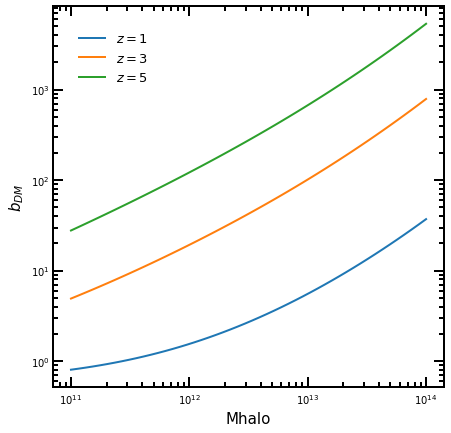

In [14]:
# plot Dark matter bias
m=np.logspace(11, 14)
pz1=lt.bias_dm(m,1.0)
pz3=lt.bias_dm(m,3.0)
pz5=lt.bias_dm(m,5.0)

plt.plot(m,pz1,lw=lw,label=r'$z=1$')
plt.plot(m,pz3,lw=lw,label=r'$z=3$')
plt.plot(m,pz5,lw=lw,label=r'$z=5$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mhalo')
plt.ylabel(r'$b_{DM}$')
plt.legend(loc=0, frameon=False)

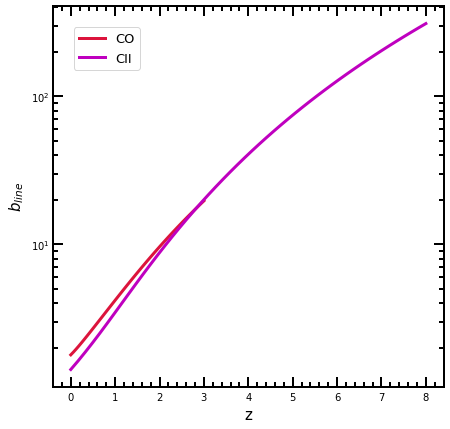

In [15]:
# plot bias of CII lines
z_c2=np.linspace(0, 8, num=50)
z_co=np.linspace(0, 3, num=50)

bline_co=[lt.b_line(zz, line_name='CO10') for zz in z_co]
bline_c2=[lt.b_line(zz, line_name='CII') for zz in z_c2]

plt.plot(z_co,bline_co,lw=3, color='crimson',label="CO")
plt.plot(z_c2,bline_c2,lw=3, color='m',label="CII")
plt.yscale('log')
plt.xlabel('z')
plt.ylabel(r'$b_{line}$')
plt.legend(loc=0)

In [17]:
# plot all the power spectra
zline=3.0
nu_rest_cii=1900 #GhZ
k=np.logspace(-3, 2, num=20)
line_name='CII'
pkshot_cii=[lt.Pk_line_te(kk,zline,nu_rest_cii,line_name=line_name,label='shot') for kk in k]
pkclus_cii=[lt.Pk_line_te(kk,zline,nu_rest_cii,line_name=line_name,label='clustering') for kk in k]
pktotal_cii=[lt.Pk_line_te(kk,zline,nu_rest_cii,line_name=line_name,label='total') for kk in k]

AttributeError: module 'limpy.theory' has no attribute 'Pk_line_te'

In [ ]:
# plot all the power spectra
zline=3.0
nu_rest_co=115 #GhZ
k=np.logspace(-3, 2, num=20)
line_name='CO10'
pkshot_co=[lt.Pk_line_te(kk,zline,nu_rest_co,line_name=line_name,label='shot') for kk in k]
pkclus_co=[lt.Pk_line_te(kk,zline,nu_rest_co,line_name=line_name,label='clustering') for kk in k]
pktotal_co=[lt.Pk_line_te(kk,zline,nu_rest_co,line_name=line_name,label='total') for kk in k]

In [ ]:
plt.plot(k, k**2*pkshot_cii/2.0/np.pi, lw=3, ls='--', color='r', label="shot noise")
plt.plot(k, k**2*pkclus_cii/2.0/np.pi, lw=3, ls=':', color='r',label="clustering")
plt.plot(k, k**2*pktotal_cii/2.0/np.pi, lw=4, color='r',label="CII, total")

plt.plot(k, k**2*pkshot_co/2.0/np.pi, lw=3, ls='--', color='g', label="shot noise")
plt.plot(k, k**2*pkclus_co/2.0/np.pi, lw=3, ls=':', color='g',label="clustering")
plt.plot(k, k**2*pktotal_co/2.0/np.pi, lw=4, color='g',label="CO(J=1-0), total")

plt.ylabel(r'$\Delta^2_k\,\,(Jy/sr)^2$')
plt.xlabel(r'$k$')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc=0, frameon=False)
plt.xlim(1e-1,1e1)